# Entrega 3 - Analise Exploratoria, Consultas SQL e Testes de Hipoteses

**Projeto Final - Ciencia de Dados (UTFPR)**

Este notebook implementa os requisitos da Entrega 3 descritos no PDF: dados em formato tidy, exportacao Parquet, 5+ consultas SQL documentadas, analises univariadas/bivariadas/multivariadas, visualizacoes interpretadas e teste preliminar de hipoteses.

## Planejamento executado

1. Carregar o dataset integrado da Entrega 2.
2. Reconstruir `quantidade_produzida_t` a partir do CSV bruto do IBGE.
3. Preparar tabelas tidy anuais e mensais para consultas DuckDB.
4. Criar consultas SQL para janelas climaticas anteriores aos meses de colheita.
5. Testar H2 comparando culturas de exportacao e mercado interno com cambio e Selic.
6. Explorar H3 com EDA e um teste preditivo preliminar.

**Observacao metodologica:** a base climatica processada esta mensal. Assim, as janelas de dias sao aproximadas por meses completos anteriores ao mes de colheita. Para soja, por exemplo, colheita em marco implica `chuva_0_30 = fevereiro`, `chuva_30_60 = janeiro`, `chuva_60_90 = dezembro do ano anterior` e `chuva_90_120 = novembro do ano anterior`.


In [1]:
from pathlib import Path
import csv
import warnings

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT.name == 'final':
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
COMMODITY_DIR = DATA_DIR / 'commodity'
ECONOMIC_DIR = DATA_DIR / 'economic'
FINAL_DIR = DATA_DIR / 'final'
FINAL_DIR.mkdir(parents=True, exist_ok=True)


## 1. Carga e preparacao tidy

O dataset integrado da Entrega 2 esta em granularidade mensal e ja combina os blocos de commodity, clima e indicadores SGS/BCB. Como a hipotese H3 fala em output de colheita, a quantidade produzida anual e recuperada do CSV bruto do IBGE.


In [2]:
parquet_path = PROCESSED_DIR / 'dataset_final.parquet'
csv_path = PROCESSED_DIR / 'dataset_integrado.csv'

if parquet_path.exists():
    df_integrado = pd.read_parquet(parquet_path)
    fonte = parquet_path.name
elif csv_path.exists():
    df_integrado = pd.read_csv(csv_path)
    fonte = csv_path.name
else:
    raise FileNotFoundError('Dataset integrado nao encontrado. Execute a Entrega 2 antes.')

df_integrado['ano'] = pd.to_numeric(df_integrado['ano'], errors='coerce').astype('Int64')
df_integrado['mes'] = pd.to_numeric(df_integrado['mes'], errors='coerce').astype('Int64')

display(Markdown(f'**Dataset carregado:** `{fonte}` com {len(df_integrado):,} linhas e {df_integrado.shape[1]} colunas.'))
display(df_integrado.head())
display(df_integrado[['cultura', 'tipo_cultura']].drop_duplicates().sort_values('cultura'))


**Dataset carregado:** `dataset_final.parquet` com 17,784 linhas e 29 colunas.

,uf,ano,cultura,area_plantada_ha,area_plantada_percentual,area_colhida_ha,area_colhida_percentual,quantidade_produzida_t,rendimento_medio_producao_kg_ha,valor_producao_mil_reais,...,vento_media_ms,n_estacoes,anomalia_precip,icbr_agropecuaria_brl,icbr_agropecuaria_usd,icbr_energia_brl,icbr_energia_usd,ipca_monitorados_total,dolar_comercial_venda,ibc_br
0,AC,2010,Cana_de_acucar,2769.0,2.15,1999.0,1.62,107251.0,53652.0,7209.0,...,1.60,2.0,0.994857,101.01,129.96,63.19,81.26,0.83,1.779820,87.94934
1,AC,2010,Cana_de_acucar,2769.0,2.15,1999.0,1.62,107251.0,53652.0,7209.0,...,1.40,2.0,0.379624,102.85,127.54,62.53,77.46,0.42,1.841633,89.20680
2,AC,2010,Cana_de_acucar,2769.0,2.15,1999.0,1.62,107251.0,53652.0,7209.0,...,1.25,2.0,0.209453,95.08,121.76,57.54,73.62,-0.14,1.785843,100.27383
3,AC,2010,Cana_de_acucar,2769.0,2.15,1999.0,1.62,107251.0,53652.0,7209.0,...,1.30,2.0,-0.596522,92.12,119.91,57.75,75.10,0.14,1.756570,95.67957
4,AC,2010,Cana_de_acucar,2769.0,2.15,1999.0,1.62,107251.0,53652.0,7209.0,...,1.30,2.0,-1.213626,92.38,116.54,58.99,74.37,0.33,1.813190,95.43544


,cultura,tipo_cultura
0,Cana_de_acucar,Industrial
12,Mandioca,Raiz
24,Milho,Grao
36,Soja,Grao


In [3]:
UF_MAP = {
    'Rondônia': 'RO', 'Rondonia': 'RO', 'Acre': 'AC', 'Amazonas': 'AM', 'Roraima': 'RR',
    'Pará': 'PA', 'Para': 'PA', 'Amapá': 'AP', 'Amapa': 'AP', 'Tocantins': 'TO',
    'Maranhão': 'MA', 'Maranhao': 'MA', 'Piauí': 'PI', 'Piaui': 'PI', 'Ceará': 'CE', 'Ceara': 'CE',
    'Rio Grande do Norte': 'RN', 'Paraíba': 'PB', 'Paraiba': 'PB', 'Pernambuco': 'PE', 'Alagoas': 'AL',
    'Sergipe': 'SE', 'Bahia': 'BA', 'Minas Gerais': 'MG', 'Espírito Santo': 'ES', 'Espirito Santo': 'ES',
    'Rio de Janeiro': 'RJ', 'São Paulo': 'SP', 'Sao Paulo': 'SP', 'Paraná': 'PR', 'Parana': 'PR',
    'Santa Catarina': 'SC', 'Rio Grande do Sul': 'RS', 'Mato Grosso do Sul': 'MS',
    'Mato Grosso': 'MT', 'Goiás': 'GO', 'Goias': 'GO', 'Distrito Federal': 'DF'
}
CULTURA_MAP = {
    'Cana-de-açúcar': 'Cana_de_acucar', 'Cana-de-acucar': 'Cana_de_acucar',
    'Mandioca': 'Mandioca', 'Milho (em grão)': 'Milho', 'Milho (em grao)': 'Milho',
    'Soja (em grão)': 'Soja', 'Soja (em grao)': 'Soja'
}

def parse_ibge_variable(path, variable_prefix, value_name):
    with open(path, newline='', encoding='utf-8-sig') as f:
        rows = list(csv.reader(f, delimiter=';'))
    start = next(i for i, row in enumerate(rows) if row and row[0].startswith(variable_prefix))
    year_idx = next(i for i in range(start + 1, len(rows)) if rows[i] and rows[i][0] == 'Unidade da Federação' and any(c.isdigit() for c in rows[i][1:]))
    product_idx = year_idx + 1
    year_row, product_row = rows[year_idx], rows[product_idx]
    years, current_year = [], None
    for cell in year_row[1:]:
        if cell.strip().isdigit():
            current_year = int(cell.strip())
        years.append(current_year)
    records = []
    for row in rows[product_idx + 1:]:
        if not row or row[0].startswith('Fonte:') or row[0].startswith('Tabela '):
            break
        uf = UF_MAP.get(row[0])
        if uf is None:
            continue
        for pos, raw in enumerate(row[1:]):
            if pos >= len(product_row) - 1 or pos >= len(years):
                continue
            cultura = CULTURA_MAP.get(product_row[pos + 1])
            ano = years[pos]
            if cultura is None or ano is None:
                continue
            value = str(raw).strip().replace('.', '').replace(',', '.')
            value = 0.0 if value == '-' else (np.nan if value in {'', '...', 'X'} else pd.to_numeric(value, errors='coerce'))
            records.append({'uf': uf, 'ano': ano, 'cultura': cultura, value_name: value})
    return pd.DataFrame(records)

df_producao = parse_ibge_variable(
    COMMODITY_DIR / 'yearly-production-per-state-historical.csv',
    'Variável - Quantidade produzida',
    'quantidade_produzida_t'
).dropna(subset=['quantidade_produzida_t'])

display(df_producao.head())
display(Markdown(f'**Registros de producao reconstruidos:** {len(df_producao):,}'))


,uf,ano,cultura,quantidade_produzida_t
0,RO,2010,Cana_de_acucar,233527.0
1,RO,2010,Mandioca,505004.0
2,RO,2010,Milho,365980.0
3,RO,2010,Soja,385388.0
4,RO,2011,Cana_de_acucar,218975.0


**Registros de producao reconstruidos:** 1,539

In [4]:
def read_bcb_series(path, encoding='utf-8'):
    df = pd.read_csv(path, sep=';', encoding=encoding)
    value_col = [c for c in df.columns if c != 'Data'][0]
    df = df.rename(columns={value_col: 'valor'})
    valor_limpo = df['valor'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    df['valor'] = pd.to_numeric(valor_limpo, errors='coerce')
    return df.dropna(subset=['valor']).copy()

selic_mensal = read_bcb_series(ECONOMIC_DIR / 'selic-annualized-accumulated-2010-2026.csv', encoding='latin1')
selic_mensal['data'] = pd.to_datetime('01/' + selic_mensal['Data'].astype(str), format='%d/%m/%Y', errors='coerce')
selic_mensal = selic_mensal.dropna(subset=['data']).copy()
selic_mensal['ano'] = selic_mensal['data'].dt.year

agg_economia = {
    'cambio_medio_anual': ('dolar_comercial_venda', 'mean'),
    'cambio_desvio_anual': ('dolar_comercial_venda', 'std'),
}
for col in ['icbr_agropecuaria_brl', 'icbr_agropecuaria_usd', 'icbr_energia_brl', 'icbr_energia_usd', 'ipca_monitorados_total', 'ibc_br']:
    if col in df_integrado.columns:
        agg_economia[f'{col}_media_anual'] = (col, 'mean')

economia_anual = (
    df_integrado.groupby('ano', as_index=False)
    .agg(**agg_economia)
    .merge(selic_mensal.groupby('ano', as_index=False).agg(selic_media_anual=('valor', 'mean')), on='ano', how='left')
)

display(economia_anual.head())


,ano,cambio_medio_anual,cambio_desvio_anual,icbr_agropecuaria_brl_media_anual,icbr_agropecuaria_usd_media_anual,icbr_energia_brl_media_anual,icbr_energia_usd_media_anual,ipca_monitorados_total_media_anual,ibc_br_media_anual,selic_media_anual
0,2010,1.760145,0.047447,101.675000,132.455000,59.428333,77.166667,0.257500,95.811427,9.802500
1,2011,1.674971,0.087945,126.304167,172.900000,64.304167,87.969167,0.503333,98.846652,11.665000
2,2012,1.954591,0.121978,131.551667,154.165000,63.081667,73.785833,0.299167,99.737774,8.530833
3,2013,2.157628,0.138797,135.506667,143.877500,71.638333,75.866667,0.128333,102.636964,8.178333
4,2014,2.353553,0.129662,149.209167,145.079167,78.220833,76.212500,0.433333,102.375257,10.855833


In [5]:
df_agro_anual = duckdb.sql('''
    SELECT
        uf,
        ano,
        cultura,
        ANY_VALUE(tipo_cultura) AS tipo_cultura,
        ANY_VALUE(regiao) AS regiao,
        MAX(area_plantada_ha) AS area_plantada_ha,
        SUM(precip_total_mm) AS precip_total_anual_mm,
        AVG(temp_media_c) AS temp_media_anual_c,
        AVG(dolar_comercial_venda) AS cambio_medio_no_ano,
        STDDEV_SAMP(dolar_comercial_venda) AS cambio_desvio_no_ano
    FROM df_integrado
    GROUP BY uf, ano, cultura
''').fetchdf()

df_agro_anual = df_agro_anual.merge(df_producao, on=['uf', 'ano', 'cultura'], how='left')
df_agro_anual = df_agro_anual.merge(economia_anual, on='ano', how='left')
df_agro_anual['grupo_mercado'] = np.where(df_agro_anual['cultura'].isin(['Soja', 'Milho', 'Cana_de_acucar']), 'Exportacao', 'Mercado interno')
df_agro_anual['produtividade_t_ha'] = np.divide(
    df_agro_anual['quantidade_produzida_t'],
    df_agro_anual['area_plantada_ha'],
    out=np.zeros(len(df_agro_anual), dtype=float),
    where=df_agro_anual['area_plantada_ha'].to_numpy() != 0
)

out_path = FINAL_DIR / 'dataset_entrega3_tidy.parquet'
df_agro_anual.to_parquet(out_path, index=False)

display(Markdown(f'**Dataset tidy anual exportado:** `{out_path.relative_to(PROJECT_ROOT)}`'))
display(df_agro_anual.head())


**Dataset tidy anual exportado:** `data\final\dataset_entrega3_tidy.parquet`

,uf,ano,cultura,tipo_cultura,regiao,area_plantada_ha,precip_total_anual_mm,temp_media_anual_c,cambio_medio_no_ano,cambio_desvio_no_ano,...,cambio_desvio_anual,icbr_agropecuaria_brl_media_anual,icbr_agropecuaria_usd_media_anual,icbr_energia_brl_media_anual,icbr_energia_usd_media_anual,ipca_monitorados_total_media_anual,ibc_br_media_anual,selic_media_anual,grupo_mercado,produtividade_t_ha
0,AC,2021,Milho,Grao,Norte,34105.0,2018.394209,25.386439,5.395027,0.199814,...,0.191384,358.682500,151.984167,173.624167,73.500000,1.314167,97.229239,4.419167,Exportacao,3.104677
1,AL,2010,Mandioca,Raiz,Nordeste,20397.0,1246.666667,25.655698,1.760145,0.049536,...,0.047447,101.675000,132.455000,59.428333,77.166667,0.257500,95.811427,9.802500,Mercado interno,15.601853
2,AL,2020,Soja,Grao,Nordeste,1224.0,921.426817,26.078350,5.155840,0.474499,...,0.454480,253.608333,112.814167,98.466667,44.050833,0.220000,93.145353,2.789167,Exportacao,3.790850
3,AM,2010,Soja,Grao,Norte,180.0,1439.758086,26.996249,1.760145,0.049536,...,0.047447,101.675000,132.455000,59.428333,77.166667,0.257500,95.811427,9.802500,Exportacao,3.000000
4,AM,2012,Soja,Grao,Norte,220.0,2251.281826,26.630024,1.954591,0.127351,...,0.121978,131.551667,154.165000,63.081667,73.785833,0.299167,99.737774,8.530833,Exportacao,3.000000


## 2. Consultas SQL para janelas climaticas antes da colheita

Calendario solicitado:

| Cultura | Mes de colheita |
|---|---:|
| Soja | marco |
| Algodao | junho |
| Trigo | outubro |
| Aveia | outubro |
| Cevada | outubro |
| Canola | outubro |
| Girassol | junho |

O dataset integrado atual contem apenas `Cana_de_acucar`, `Mandioca`, `Milho` e `Soja`; portanto, das culturas solicitadas, somente `Soja` esta disponivel para as janelas climaticas.


In [6]:
calendario_colheita = pd.DataFrame({
    'cultura': ['Soja', 'Algodao', 'Trigo', 'Aveia', 'Cevada', 'Canola', 'Girassol'],
    'mes_colheita': [3, 6, 10, 10, 10, 10, 6]
})
indisponiveis = sorted(set(calendario_colheita['cultura']) - set(df_integrado['cultura'].unique()))
display(calendario_colheita)
display(Markdown('**Culturas ausentes no dataset integrado:** ' + ', '.join(indisponiveis)))


,cultura,mes_colheita
0,Soja,3
1,Algodao,6
2,Trigo,10
3,Aveia,10
4,Cevada,10
5,Canola,10
6,Girassol,6


**Culturas ausentes no dataset integrado:** Algodao, Aveia, Canola, Cevada, Girassol, Trigo

In [7]:
con = duckdb.connect()
con.register('df_integrado', df_integrado)
con.register('df_agro_anual', df_agro_anual)
con.register('calendario_colheita', calendario_colheita)
con.register('economia_anual', economia_anual)

consulta_clima_colheita = '''
WITH base AS (
    SELECT DISTINCT
        i.uf,
        i.ano,
        i.cultura,
        c.mes_colheita,
        MAKE_DATE(i.ano, c.mes_colheita, 1) AS data_colheita
    FROM df_integrado i
    INNER JOIN calendario_colheita c USING (cultura)
), offsets AS (
    SELECT * FROM (VALUES
        (1, '0_30'),
        (2, '30_60'),
        (3, '60_90'),
        (4, '90_120')
    ) AS t(offset_meses, janela)
), alvo AS (
    SELECT
        b.uf,
        b.ano,
        b.cultura,
        b.mes_colheita,
        o.janela,
        EXTRACT(YEAR FROM b.data_colheita - o.offset_meses * INTERVAL '1 month')::INTEGER AS ano_clima,
        EXTRACT(MONTH FROM b.data_colheita - o.offset_meses * INTERVAL '1 month')::INTEGER AS mes_clima
    FROM base b
    CROSS JOIN offsets o
), clima_janelas AS (
    SELECT
        a.uf,
        a.ano,
        a.cultura,
        a.mes_colheita,
        a.janela,
        w.precip_total_mm,
        w.temp_media_c
    FROM alvo a
    LEFT JOIN df_integrado w
        ON w.uf = a.uf
       AND w.ano = a.ano_clima
       AND w.mes = a.mes_clima
       AND w.cultura = a.cultura
)
SELECT
    uf,
    ano,
    cultura,
    mes_colheita,
    SUM(CASE WHEN janela = '0_30' THEN precip_total_mm END) AS chuva_0_30,
    SUM(CASE WHEN janela = '30_60' THEN precip_total_mm END) AS chuva_30_60,
    SUM(CASE WHEN janela = '60_90' THEN precip_total_mm END) AS chuva_60_90,
    SUM(CASE WHEN janela = '90_120' THEN precip_total_mm END) AS chuva_90_120,
    SUM(CASE WHEN janela IN ('30_60', '60_90') THEN precip_total_mm END) AS chuva_30_90,
    SUM(CASE WHEN janela IN ('60_90', '90_120') THEN precip_total_mm END) AS chuva_60_120,
    AVG(CASE WHEN janela = '0_30' THEN temp_media_c END) AS temp_0_30,
    AVG(CASE WHEN janela = '30_60' THEN temp_media_c END) AS temp_30_60,
    AVG(CASE WHEN janela = '60_90' THEN temp_media_c END) AS temp_60_90,
    AVG(CASE WHEN janela = '90_120' THEN temp_media_c END) AS temp_90_120,
    AVG(CASE WHEN janela IN ('30_60', '60_90') THEN temp_media_c END) AS temp_30_90,
    AVG(CASE WHEN janela IN ('60_90', '90_120') THEN temp_media_c END) AS temp_60_120
FROM clima_janelas
GROUP BY uf, ano, cultura, mes_colheita
ORDER BY cultura, uf, ano
'''

df_clima_colheita = con.execute(consulta_clima_colheita).fetchdf()
con.register('df_clima_colheita', df_clima_colheita)

display(Markdown('### Consulta SQL 1 - chuva acumulada e temperatura media nas janelas pre-colheita'))
display(df_clima_colheita.head(10))


### Consulta SQL 1 - chuva acumulada e temperatura media nas janelas pre-colheita

,uf,ano,cultura,mes_colheita,chuva_0_30,chuva_30_60,chuva_60_90,chuva_90_120,chuva_30_90,chuva_60_120,temp_0_30,temp_30_60,temp_60_90,temp_90_120,temp_30_90,temp_60_120
0,AC,2010,Soja,3,207.000000,272.800000,NaN,NaN,272.800000,NaN,25.950000,25.50,NaN,NaN,25.500000,NaN
1,AC,2011,Soja,3,166.400000,178.500000,169.200000,161.800000,347.700000,331.000000,24.650000,25.00,25.300000,25.450000,25.150000,25.37500
2,AC,2012,Soja,3,394.433333,399.363636,291.800000,213.745455,691.163636,505.545455,24.500000,24.55,25.200000,26.000000,24.875000,25.60000
3,AC,2013,Soja,3,225.700000,430.400000,332.900000,294.300000,763.300000,627.200000,25.300000,25.30,24.950000,25.750000,25.125000,25.35000
4,AC,2014,Soja,3,232.300000,329.500000,234.900000,276.600000,564.400000,511.500000,25.000000,25.05,25.550000,25.350000,25.300000,25.45000
5,AC,2015,Soja,3,328.400000,389.500000,305.581818,213.315455,695.081818,518.897273,25.100000,24.50,25.150000,25.906439,24.825000,25.52822
6,AC,2016,Soja,3,167.000000,146.000000,308.700000,231.200000,454.700000,539.900000,25.900000,26.35,25.750000,26.450000,26.050000,26.10000
7,AC,2017,Soja,3,236.533333,278.413636,334.900000,160.370000,613.313636,495.270000,25.161538,24.75,25.350000,25.750000,25.050000,25.55000
8,AC,2018,Soja,3,233.792308,243.350000,324.481818,242.670000,567.831818,567.151818,25.253846,25.30,25.466667,25.877273,25.383333,25.67197
9,AC,2019,Soja,3,338.892308,315.750000,244.981818,225.270000,560.731818,470.251818,25.403846,25.40,25.366667,25.877273,25.383333,25.62197


**Interpretacao da Consulta 1:** a consulta cria as variaveis `chuva_0_30`, `chuva_30_60`, `chuva_60_90`, `chuva_90_120`, `chuva_30_90` e `chuva_60_120`, alem das temperaturas medias equivalentes. Ela usa SQL com CTEs, calendario de colheita e deslocamento temporal de meses.


## 3. Consultas SQL analiticas para H2 e H3


In [8]:
resultado_temporal = con.execute('''
WITH anual AS (
    SELECT
        ano,
        cultura,
        SUM(area_plantada_ha) AS area_total_ha,
        SUM(quantidade_produzida_t) AS producao_total_t,
        AVG(produtividade_t_ha) AS produtividade_media_t_ha
    FROM df_agro_anual
    GROUP BY ano, cultura
), evolucao AS (
    SELECT
        *,
        LAG(producao_total_t) OVER (PARTITION BY cultura ORDER BY ano) AS producao_ano_anterior,
        100 * (producao_total_t - LAG(producao_total_t) OVER (PARTITION BY cultura ORDER BY ano))
            / NULLIF(LAG(producao_total_t) OVER (PARTITION BY cultura ORDER BY ano), 0) AS variacao_producao_pct
    FROM anual
)
SELECT * FROM evolucao
ORDER BY cultura, ano
''').fetchdf()

display(Markdown('### Consulta SQL 2 - tendencia temporal de area, producao e produtividade'))
display(resultado_temporal.head(12))


### Consulta SQL 2 - tendencia temporal de area, producao e produtividade

,ano,cultura,area_total_ha,producao_total_t,produtividade_media_t_ha,producao_ano_anterior,variacao_producao_pct
0,2010,Cana_de_acucar,9164193.0,717462338.0,61.425382,NaN,NaN
1,2011,Cana_de_acucar,9616051.0,734004676.0,61.803382,717462338.0,2.305673
2,2012,Cana_de_acucar,9777093.0,722925150.0,59.880917,734004676.0,-1.509463
3,2013,Cana_de_acucar,10222568.0,768085984.0,60.944244,722925150.0,6.246958
4,2014,Cana_de_acucar,10453899.0,736105679.0,60.985784,768085984.0,-4.163636
5,2015,Cana_de_acucar,10179537.0,750286302.0,61.875653,736105679.0,1.926438
6,2016,Cana_de_acucar,10242457.0,768591146.0,58.585978,750286302.0,2.439715
7,2017,Cana_de_acucar,10233020.0,758643230.0,57.545057,768591146.0,-1.294305
8,2018,Cana_de_acucar,10045484.0,747554743.0,57.847839,758643230.0,-1.461621
9,2019,Cana_de_acucar,10120463.0,753468375.0,60.674507,747554743.0,0.791063


In [9]:
resultado_h2_grupos = con.execute('''
WITH grupo_ano AS (
    SELECT
        ano,
        grupo_mercado,
        SUM(area_plantada_ha) AS area_total_ha,
        SUM(quantidade_produzida_t) AS producao_total_t,
        AVG(cambio_medio_anual) AS cambio_medio_anual,
        AVG(cambio_desvio_anual) AS cambio_desvio_anual,
        AVG(selic_media_anual) AS selic_media_anual
    FROM df_agro_anual
    WHERE quantidade_produzida_t IS NOT NULL
    GROUP BY ano, grupo_mercado
), variacao AS (
    SELECT
        *,
        100 * (area_total_ha - LAG(area_total_ha) OVER (PARTITION BY grupo_mercado ORDER BY ano))
            / NULLIF(LAG(area_total_ha) OVER (PARTITION BY grupo_mercado ORDER BY ano), 0) AS variacao_area_pct,
        100 * (producao_total_t - LAG(producao_total_t) OVER (PARTITION BY grupo_mercado ORDER BY ano))
            / NULLIF(LAG(producao_total_t) OVER (PARTITION BY grupo_mercado ORDER BY ano), 0) AS variacao_producao_pct
    FROM grupo_ano
)
SELECT * FROM variacao
ORDER BY grupo_mercado, ano
''').fetchdf()

display(Markdown('### Consulta SQL 3 - H2: exportacao vs mercado interno com cambio e juros'))
display(resultado_h2_grupos.head(12))


### Consulta SQL 3 - H2: exportacao vs mercado interno com cambio e juros

,ano,grupo_mercado,area_total_ha,producao_total_t,cambio_medio_anual,cambio_desvio_anual,selic_media_anual,variacao_area_pct,variacao_producao_pct
0,2010,Exportacao,45458467.0,841566232.0,1.760145,0.047447,9.802500,NaN,NaN
1,2011,Exportacao,47243730.0,864458478.0,1.674971,0.087945,11.665000,3.927240,2.720195
2,2012,Exportacao,49921440.0,859821017.0,1.954591,0.121978,8.530833,5.667863,-0.536459
3,2013,Exportacao,53861829.0,930027995.0,2.157628,0.138797,8.178333,7.893180,8.165301
4,2014,Exportacao,56583070.0,902698513.0,2.353553,0.129662,10.855833,5.052263,-2.938566
5,2015,Exportacao,58205440.0,932963615.0,3.331539,0.424282,13.366667,2.867236,3.352736
6,2016,Exportacao,59603684.0,929089920.0,3.490114,0.277150,14.079167,2.402257,-0.415203
7,2017,Exportacao,61951714.0,971199538.0,3.192013,0.061688,10.079167,3.939404,4.532351
8,2018,Exportacao,61385238.0,947683296.0,3.654437,0.286606,6.483333,-0.914383,-2.421361
9,2019,Exportacao,63789541.0,968751133.0,3.945086,0.149718,5.940000,3.916745,2.223088


In [10]:
resultado_h2_corr = con.execute('''
SELECT
    grupo_mercado,
    COUNT(*) AS n_observacoes,
    CORR(area_plantada_ha, cambio_medio_anual) AS corr_area_cambio,
    CORR(area_plantada_ha, cambio_desvio_anual) AS corr_area_volatilidade_cambio,
    CORR(area_plantada_ha, selic_media_anual) AS corr_area_selic,
    CORR(quantidade_produzida_t, cambio_medio_anual) AS corr_producao_cambio,
    CORR(quantidade_produzida_t, cambio_desvio_anual) AS corr_producao_volatilidade_cambio,
    CORR(quantidade_produzida_t, selic_media_anual) AS corr_producao_selic
FROM df_agro_anual
WHERE quantidade_produzida_t IS NOT NULL
GROUP BY grupo_mercado
ORDER BY grupo_mercado
''').fetchdf()

display(Markdown('### Consulta SQL 4 - H2: correlacoes por grupo de mercado'))
display(resultado_h2_corr.round(3))


### Consulta SQL 4 - H2: correlacoes por grupo de mercado

,grupo_mercado,n_observacoes,corr_area_cambio,corr_area_volatilidade_cambio,corr_area_selic,corr_producao_cambio,corr_producao_volatilidade_cambio,corr_producao_selic
0,Exportacao,1118,0.057,0.014,-0.007,0.022,0.014,0.003
1,Mercado interno,364,-0.118,-0.047,0.038,-0.087,-0.029,0.041


In [11]:
resultado_concentracao = con.execute('''
WITH cultura_uf AS (
    SELECT cultura, uf, SUM(quantidade_produzida_t) AS producao_uf_t
    FROM df_agro_anual
    WHERE quantidade_produzida_t IS NOT NULL
    GROUP BY cultura, uf
), ranked AS (
    SELECT
        *,
        SUM(producao_uf_t) OVER (PARTITION BY cultura) AS producao_cultura_t,
        ROW_NUMBER() OVER (PARTITION BY cultura ORDER BY producao_uf_t DESC) AS ranking_uf
    FROM cultura_uf
)
SELECT cultura, uf, ranking_uf, producao_uf_t,
       100 * producao_uf_t / NULLIF(producao_cultura_t, 0) AS participacao_pct
FROM ranked
WHERE ranking_uf <= 5
ORDER BY cultura, ranking_uf
''').fetchdf()

display(Markdown('### Consulta SQL 5 - concentracao geografica da producao'))
display(resultado_concentracao.round(2))


### Consulta SQL 5 - concentracao geografica da producao

,cultura,uf,ranking_uf,producao_uf_t,participacao_pct
0,Cana_de_acucar,SP,1,6.384546e+09,57.02
1,Cana_de_acucar,MG,2,1.081933e+09,9.66
2,Cana_de_acucar,GO,3,1.050339e+09,9.38
3,Cana_de_acucar,MS,4,6.789267e+08,6.06
4,Cana_de_acucar,PR,5,6.403972e+08,5.72
5,Mandioca,PA,1,5.993296e+07,20.85
6,Mandioca,PR,2,5.129965e+07,17.85
7,Mandioca,BA,3,2.149444e+07,7.48
8,Mandioca,SP,4,1.846659e+07,6.42
9,Mandioca,RS,5,1.427766e+07,4.97


In [12]:
df_modelo = con.execute('''
SELECT
    a.uf, a.ano, a.cultura, a.regiao, a.grupo_mercado,
    a.area_plantada_ha, a.quantidade_produzida_t, a.produtividade_t_ha,
    a.cambio_medio_anual, a.cambio_desvio_anual, a.selic_media_anual,
    c.chuva_0_30, c.chuva_30_60, c.chuva_60_90, c.chuva_90_120, c.chuva_30_90, c.chuva_60_120,
    c.temp_0_30, c.temp_30_60, c.temp_60_90, c.temp_90_120, c.temp_30_90, c.temp_60_120
FROM df_agro_anual a
INNER JOIN df_clima_colheita c
    ON a.uf = c.uf AND a.ano = c.ano AND a.cultura = c.cultura
WHERE a.quantidade_produzida_t IS NOT NULL
''').fetchdf()
con.register('df_modelo', df_modelo)

resultado_multivariado = con.execute('''
SELECT
    cultura,
    COUNT(*) AS n_observacoes,
    CORR(quantidade_produzida_t, chuva_0_30) AS corr_prod_chuva_0_30,
    CORR(quantidade_produzida_t, chuva_30_90) AS corr_prod_chuva_30_90,
    CORR(quantidade_produzida_t, chuva_60_120) AS corr_prod_chuva_60_120,
    CORR(quantidade_produzida_t, temp_30_90) AS corr_prod_temp_30_90,
    CORR(quantidade_produzida_t, area_plantada_ha) AS corr_prod_area,
    CORR(quantidade_produzida_t, ano) AS corr_prod_ano,
    CORR(quantidade_produzida_t, cambio_medio_anual) AS corr_prod_cambio,
    CORR(quantidade_produzida_t, selic_media_anual) AS corr_prod_selic
FROM df_modelo
GROUP BY cultura
''').fetchdf()

display(Markdown('### Consulta SQL 6 - H3: correlacoes multivariadas para a base preditiva'))
display(resultado_multivariado.round(3))
display(Markdown(f'**Base H3:** {len(df_modelo):,} linhas apos cruzar producao, clima pre-colheita e economia.'))


### Consulta SQL 6 - H3: correlacoes multivariadas para a base preditiva

,cultura,n_observacoes,corr_prod_chuva_0_30,corr_prod_chuva_30_90,corr_prod_chuva_60_120,corr_prod_temp_30_90,corr_prod_area,corr_prod_ano,corr_prod_cambio,corr_prod_selic
0,Soja,364,0.076,0.183,0.193,-0.29,0.984,0.13,0.124,-0.024


**Base H3:** 364 linhas apos cruzar producao, clima pre-colheita e economia.

**Interpretacao das consultas 2 a 6:** as consultas cobrem tendencia temporal, comparacao entre exportacao e mercado interno, correlacoes economicas, concentracao geografica e montagem da base multivariada para predicao. Para H2, cambio e Selic sao variaveis nacionais anuais, entao os resultados indicam associacao exploratoria, nao causalidade.


## 4. Analise univariada: producao anual das culturas


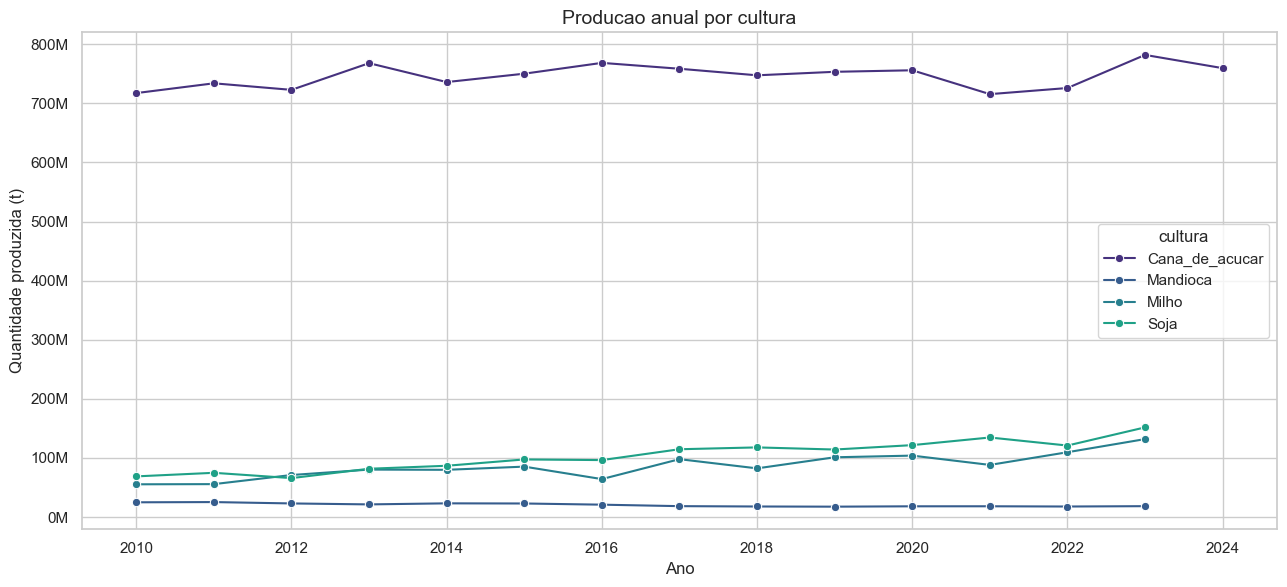

,count,mean,std,min,25%,50%,75%,max
cultura,,,,,,,,
Cana_de_acucar,15.0,7.464425e+08,20223277.75,715676690.0,7.300271e+08,750286302.0,7.591517e+08,782055201.0
Mandioca,14.0,2.053042e+07,2850513.27,17510394.0,1.812465e+07,19631743.0,2.294626e+07,25272352.0
Milho,14.0,8.617658e+07,21485323.73,55351471.0,7.326232e+07,83795027.5,1.002743e+08,131869937.0
Soja,14.0,1.033653e+08,25813170.22,65834857.0,8.294485e+07,105807940.0,1.201593e+08,151699162.0


In [13]:
producao_anual = (
    df_agro_anual.dropna(subset=['quantidade_produzida_t'])
    .groupby(['ano', 'cultura'], as_index=False)
    .agg(producao_total_t=('quantidade_produzida_t', 'sum'))
)
fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(data=producao_anual, x='ano', y='producao_total_t', hue='cultura', marker='o', ax=ax)
ax.set_title('Producao anual por cultura')
ax.set_xlabel('Ano')
ax.set_ylabel('Quantidade produzida (t)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.show()
display(producao_anual.groupby('cultura')['producao_total_t'].describe().round(2))


**Interpretacao:** a serie anual destaca diferencas de escala e tendencia. Soja, milho e cana-de-acucar representam o bloco de exportacao/industrial; mandioca funciona como contraponto de mercado interno no recorte atual.


## 5. Analise univariada: precipitacao acumulada


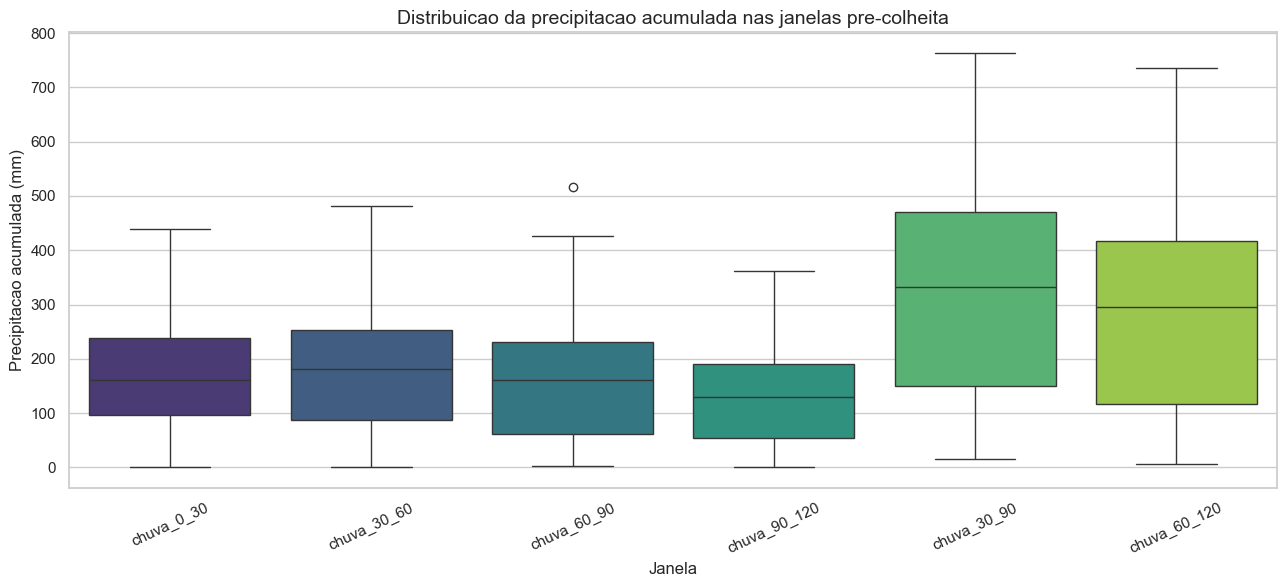

count    mean     std    min     25%     50%     75%  \
cultura janela                                                               
Soja    chuva_0_30    364.0  173.23   93.81   0.20   97.14  161.02  239.11   
        chuva_30_60   364.0  176.45   99.37   1.40   88.09  180.82  252.38   
        chuva_30_90   364.0  321.80  180.46  15.60  150.25  332.27  470.26   
        chuva_60_120  338.0  285.67  177.12   5.99  116.91  296.12  417.94   
        chuva_60_90   338.0  156.54  101.11   3.20   61.99  160.16  231.36   
        chuva_90_120  338.0  129.13   86.74   0.10   54.16  129.38  189.57   

                         max  
cultura janela                
Soja    chuva_0_30    438.54  
        chuva_30_60   482.20  
        chuva_30_90   763.30  
        chuva_60_120  735.80  
        chuva_60_90   516.88  
        chuva_90_120  361.50

In [14]:
chuva_cols = ['chuva_0_30', 'chuva_30_60', 'chuva_60_90', 'chuva_90_120', 'chuva_30_90', 'chuva_60_120']
chuva_long = df_clima_colheita.melt(id_vars=['uf', 'ano', 'cultura'], value_vars=chuva_cols, var_name='janela', value_name='precipitacao_mm').dropna()
fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=chuva_long, x='janela', y='precipitacao_mm', hue='janela', dodge=False, ax=ax)
if ax.legend_ is not None:
    ax.legend_.remove()
ax.set_title('Distribuicao da precipitacao acumulada nas janelas pre-colheita')
ax.set_xlabel('Janela')
ax.set_ylabel('Precipitacao acumulada (mm)')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()
display(chuva_long.groupby(['cultura', 'janela'])['precipitacao_mm'].describe().round(2))


**Interpretacao:** a variabilidade das janelas climaticas entre UFs e anos indica potencial explicativo para quebras e ganhos de producao, principalmente quando combinada com area plantada.


## 6. Analise univariada: area plantada por cultura


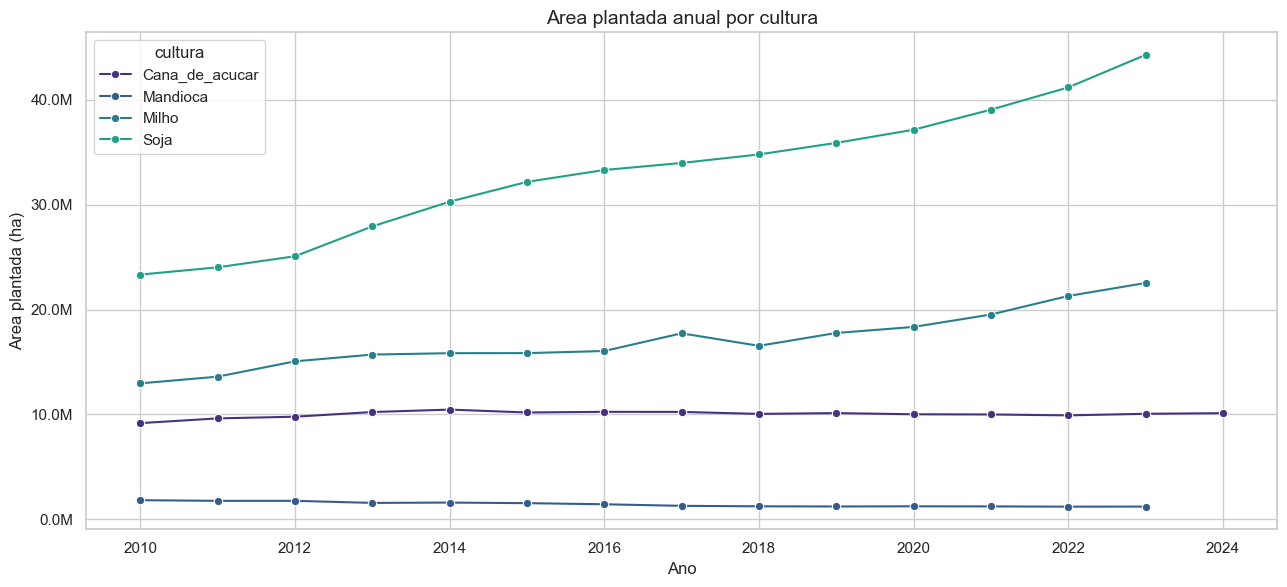

,count,mean,std,min,25%,50%,75%,max
cultura,,,,,,,,
Cana_de_acucar,15.0,10008405.87,309092.41,9164193.0,9947051.50,10055019.0,10201052.5,10453899.0
Mandioca,14.0,1425020.86,233023.18,1193693.0,1220197.25,1347235.5,1576117.5,1810804.0
Milho,14.0,17055708.14,2710349.82,12956580.0,15738402.00,16292515.0,18198118.5,22533008.0
Soja,14.0,33041779.36,6395708.20,23337694.0,28523336.50,33650453.0,36842412.5,44295786.0


In [15]:
area_anual = df_agro_anual.groupby(['ano', 'cultura'], as_index=False).agg(area_total_ha=('area_plantada_ha', 'sum'))
fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(data=area_anual, x='ano', y='area_total_ha', hue='cultura', marker='o', ax=ax)
ax.set_title('Area plantada anual por cultura')
ax.set_xlabel('Ano')
ax.set_ylabel('Area plantada (ha)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()
display(area_anual.groupby('cultura')['area_total_ha'].describe().round(2))


**Interpretacao:** area plantada e uma variavel estrutural para o output agricola. Na H2, ela tambem funciona como resposta possivel dos produtores a cambio, juros e expectativas de mercado.


## 7. Analise bivariada: producao x precipitacao


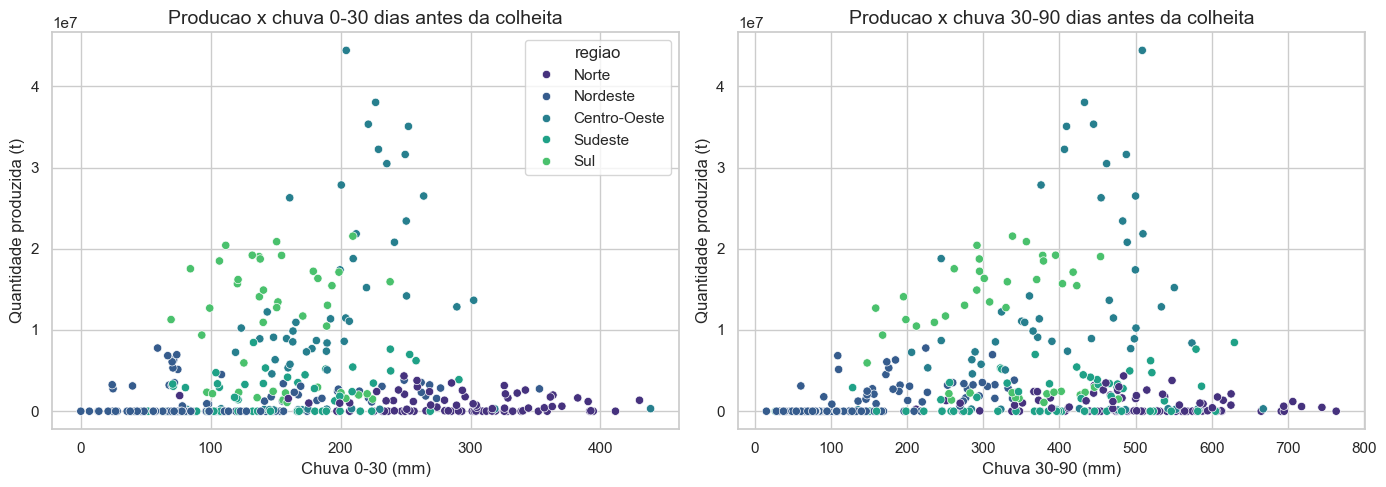

,quantidade_produzida_t,chuva_0_30,chuva_30_90,chuva_60_120
quantidade_produzida_t,1.000,0.076,0.183,0.193
chuva_0_30,0.076,1.000,0.681,0.518
chuva_30_90,0.183,0.681,1.000,0.884
chuva_60_120,0.193,0.518,0.884,1.000


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df_modelo, x='chuva_0_30', y='quantidade_produzida_t', hue='regiao', ax=axes[0])
axes[0].set_title('Producao x chuva 0-30 dias antes da colheita')
axes[0].set_xlabel('Chuva 0-30 (mm)')
axes[0].set_ylabel('Quantidade produzida (t)')
sns.scatterplot(data=df_modelo, x='chuva_30_90', y='quantidade_produzida_t', hue='regiao', ax=axes[1], legend=False)
axes[1].set_title('Producao x chuva 30-90 dias antes da colheita')
axes[1].set_xlabel('Chuva 30-90 (mm)')
axes[1].set_ylabel('Quantidade produzida (t)')
plt.tight_layout()
plt.show()
display(df_modelo[['quantidade_produzida_t', 'chuva_0_30', 'chuva_30_90', 'chuva_60_120']].corr().round(3))


**Interpretacao:** a relacao producao-precipitacao nao deve ser lida isoladamente, pois estados com maior area plantada produzem mais. A analise multivariada abaixo controla melhor esse efeito de escala.


## 8. Analise multivariada: producao x chuva x area plantada x ano


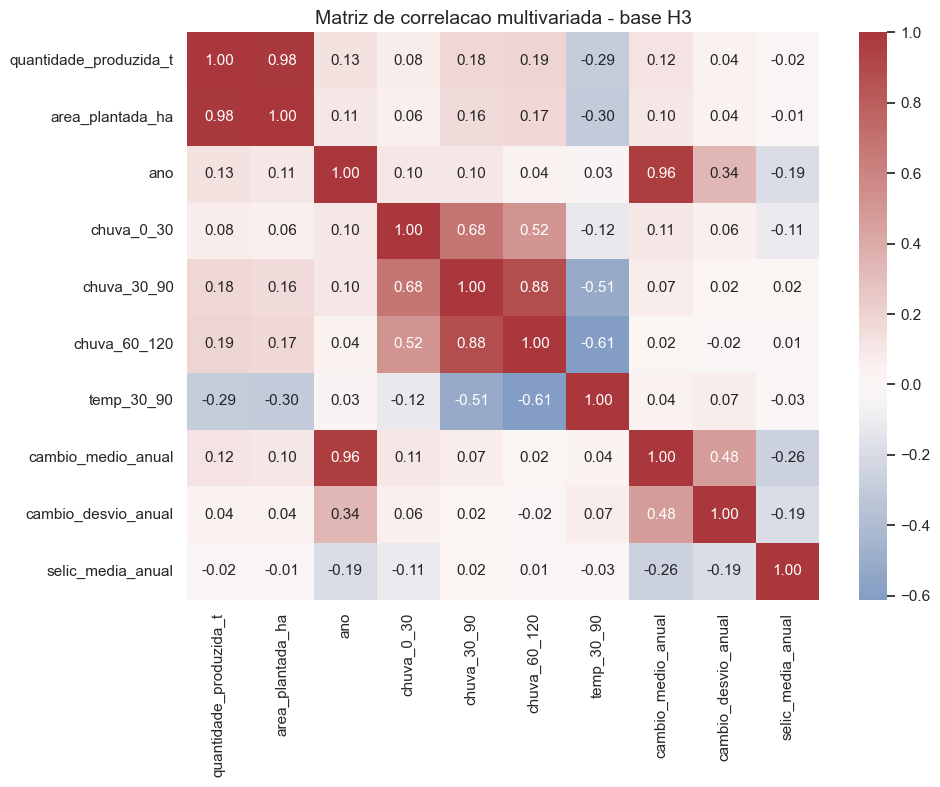

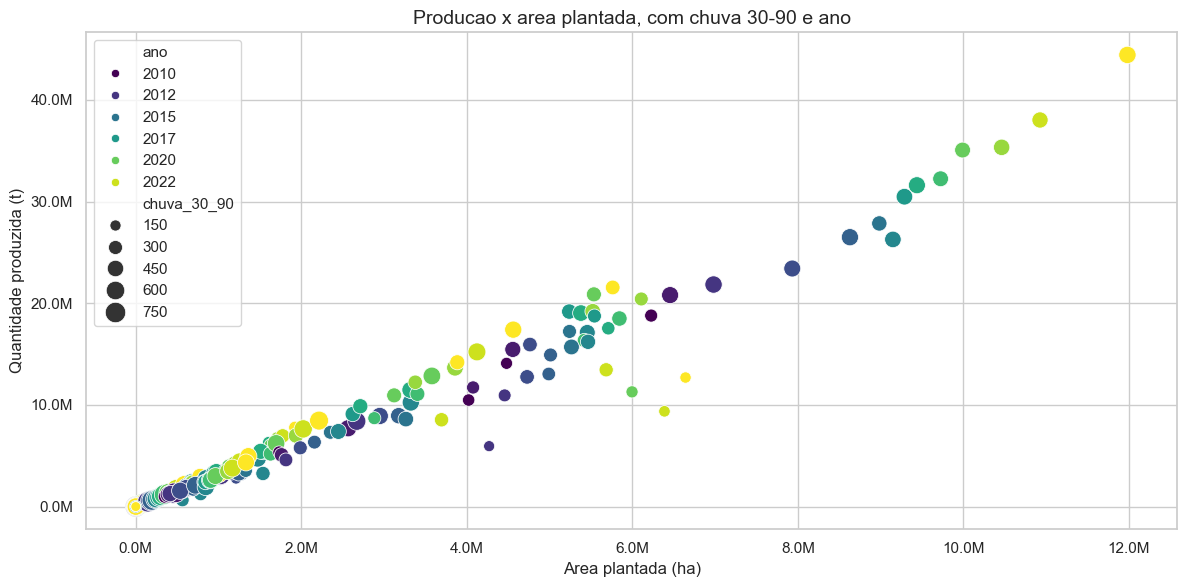

,quantidade_produzida_t
quantidade_produzida_t,1.000
area_plantada_ha,0.984
chuva_60_120,0.193
chuva_30_90,0.183
ano,0.130
cambio_medio_anual,0.124
chuva_0_30,0.076
cambio_desvio_anual,0.040
selic_media_anual,-0.024
temp_30_90,-0.290


In [17]:
variaveis_mult = [
    'quantidade_produzida_t', 'area_plantada_ha', 'ano',
    'chuva_0_30', 'chuva_30_90', 'chuva_60_120',
    'temp_30_90', 'cambio_medio_anual', 'cambio_desvio_anual', 'selic_media_anual'
]
corr = df_modelo[variaveis_mult].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax)
ax.set_title('Matriz de correlacao multivariada - base H3')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(data=df_modelo, x='area_plantada_ha', y='quantidade_produzida_t', size='chuva_30_90', hue='ano', palette='viridis', sizes=(30, 220), ax=ax)
ax.set_title('Producao x area plantada, com chuva 30-90 e ano')
ax.set_xlabel('Area plantada (ha)')
ax.set_ylabel('Quantidade produzida (t)')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()
display(corr[['quantidade_produzida_t']].sort_values('quantidade_produzida_t', ascending=False).round(3))


**Interpretacao:** a matriz mostra que area plantada deve ser baseline obrigatorio para predizer producao. Clima e economia entram como sinais complementares de curto e longo prazo para melhorar a explicacao das diferencas entre UFs e anos.


## 9. Teste preliminar da H2

**H2:** De que forma a flutuacao cambial e as taxas de juros influenciam a area plantada e a quantidade produzida de commodities de exportacao em comparacao com culturas destinadas ao mercado interno?


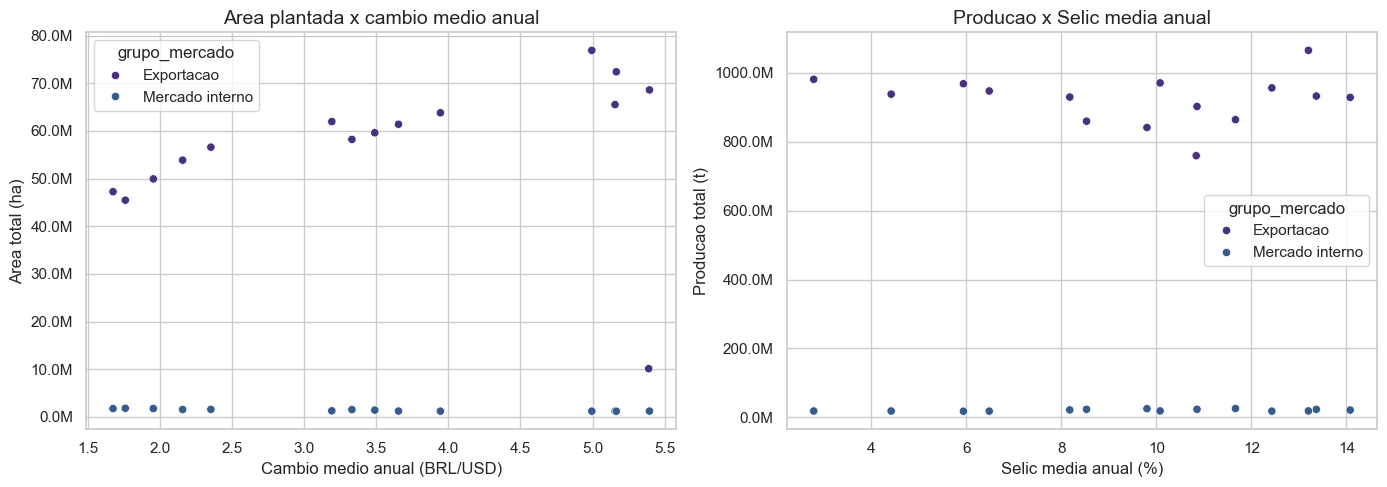

,grupo_mercado,n_observacoes,corr_area_cambio,corr_area_volatilidade_cambio,corr_area_selic,corr_producao_cambio,corr_producao_volatilidade_cambio,corr_producao_selic
0,Exportacao,1118,0.057,0.014,-0.007,0.022,0.014,0.003
1,Mercado interno,364,-0.118,-0.047,0.038,-0.087,-0.029,0.041


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=resultado_h2_grupos, x='cambio_medio_anual', y='area_total_ha', hue='grupo_mercado', ax=axes[0])
axes[0].set_title('Area plantada x cambio medio anual')
axes[0].set_xlabel('Cambio medio anual (BRL/USD)')
axes[0].set_ylabel('Area total (ha)')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
sns.scatterplot(data=resultado_h2_grupos, x='selic_media_anual', y='producao_total_t', hue='grupo_mercado', ax=axes[1])
axes[1].set_title('Producao x Selic media anual')
axes[1].set_xlabel('Selic media anual (%)')
axes[1].set_ylabel('Producao total (t)')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()
display(resultado_h2_corr.round(3))


**Conclusao preliminar da H2:** as culturas de exportacao concentram a maior escala de area e producao. As correlacoes com cambio, volatilidade cambial e Selic sugerem associacoes macroeconomicas diferentes entre grupos, mas a interpretacao precisa reconhecer que as variaveis economicas sao nacionais/anuais. O resultado orienta a proxima etapa a separar efeito de escala, efeito temporal e efeito economico.


## 10. Exploracao da H3 com teste preditivo preliminar

**H3:** E possivel predizer o output da colheita agricola unindo valores climaticos de curto prazo e dinamicas economicas de longo prazo?

Este teste e exploratorio: compara uma regressao linear com Random Forest para verificar se a base integrada tem sinal preditivo antes da modelagem formal da Entrega 4.


,modelo,MAE_t,R2
1,Random Forest,394645.008,0.968
0,Regressao Linear,622434.004,0.967


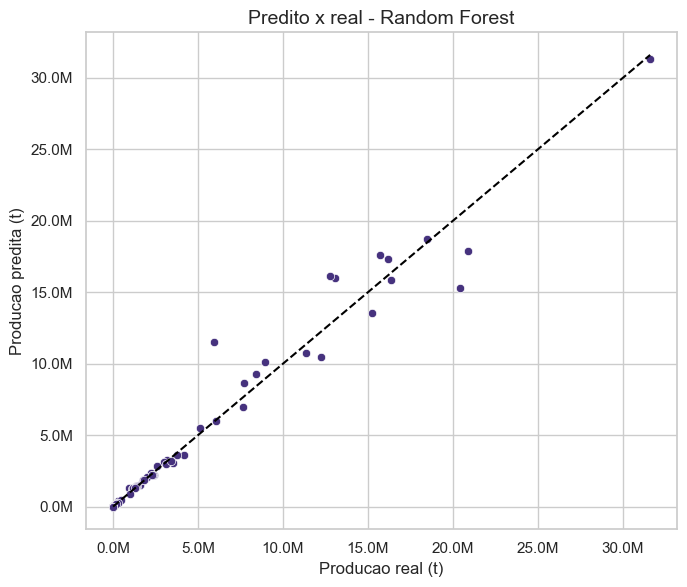

In [19]:
target = 'quantidade_produzida_t'
features_num = [
    'ano', 'area_plantada_ha',
    'chuva_0_30', 'chuva_30_60', 'chuva_60_90', 'chuva_90_120', 'chuva_30_90', 'chuva_60_120',
    'temp_0_30', 'temp_30_60', 'temp_60_90', 'temp_90_120', 'temp_30_90', 'temp_60_120',
    'cambio_medio_anual', 'cambio_desvio_anual', 'selic_media_anual'
]
features_cat = ['uf', 'regiao', 'cultura']
base_modelagem = df_modelo[features_num + features_cat + [target]].dropna(subset=[target]).copy()

X = base_modelagem[features_num + features_cat]
y = base_modelagem[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

preprocess_linear = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
])
preprocess_tree = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
])
modelos = {
    'Regressao Linear': Pipeline([('prep', preprocess_linear), ('model', LinearRegression())]),
    'Random Forest': Pipeline([('prep', preprocess_tree), ('model', RandomForestRegressor(n_estimators=300, random_state=42, min_samples_leaf=3))])
}
metricas, predicoes = [], pd.DataFrame({'real': y_test.reset_index(drop=True)})
for nome, pipe in modelos.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    metricas.append({'modelo': nome, 'MAE_t': mean_absolute_error(y_test, pred), 'R2': r2_score(y_test, pred)})
    predicoes[nome] = pred
metricas_df = pd.DataFrame(metricas).sort_values('R2', ascending=False)
display(metricas_df.round(3))

melhor_modelo = metricas_df.iloc[0]['modelo']
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(x=predicoes['real'], y=predicoes[melhor_modelo], ax=ax)
lims = [min(predicoes['real'].min(), predicoes[melhor_modelo].min()), max(predicoes['real'].max(), predicoes[melhor_modelo].max())]
ax.plot(lims, lims, color='black', linestyle='--')
ax.set_title(f'Predito x real - {melhor_modelo}')
ax.set_xlabel('Producao real (t)')
ax.set_ylabel('Producao predita (t)')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()


**Conclusao preliminar da H3:** a combinacao de area plantada, clima pre-colheita, ano e variaveis economicas forma uma base preditiva plausivel. Para a Entrega 4, recomenda-se comparar modelos com e sem clima/economia, usar validacao temporal e medir o ganho incremental sobre um baseline `area + cultura + UF`.


## 11. Insights para a etapa de modelagem

- `data/final/dataset_entrega3_tidy.parquet` organiza a base anual por UF, ano e cultura.
- A area plantada deve ser baseline obrigatorio, pois domina a escala da producao.
- As janelas climaticas pre-colheita geram features de curto prazo para H3.
- H2 e explorada por `grupo_mercado`, mas o grupo de mercado interno contem apenas mandioca no recorte atual; isso deve ser declarado como limitacao ou ampliado com mais culturas.
- A proxima etapa deve usar validacao temporal e estudo de ablation: baseline, baseline + clima, baseline + clima + economia.
